### Taking information from t-1 and t0

In [2]:
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                                     # type: ignore
import tensorflow as tf                                                                 # type: ignore
from tensorflow.keras.initializers import he_normal                                     # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore

### Importing dataset

In [3]:
data_part_1 = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/data-ML-Dakar-rnn/full-data-train-5nearest-Dakar-rnn-part1.csv", index_col=False)
data_part_2 = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/data-ML-Dakar-rnn/full-data-train-5nearest-Dakar-rnn-part2.csv", index_col=False)
data_part_3 = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/data-ML-Dakar-rnn/full-data-train-5nearest-Dakar-rnn-part3.csv", index_col=False)
data_part_4 = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/data-ML-Dakar-rnn/full-data-train-5nearest-Dakar-rnn-part4.csv", index_col=False)
test_data = pd.read_csv("/home/mendrika/mendrika-phd/codes/nflics/data-ML-Dakar-rnn/full-data-test-5nearest-Dakar-rnn.csv", index_col=False)

#### combining dataset and doing some exploratory analysis

In [4]:
data = pd.concat([data_part_1, data_part_2, data_part_3, data_part_4])

In [5]:
data = data.dropna()
test_data = test_data.dropna()

In [6]:
original_test_data = test_data.copy()

In [7]:
data

,year_t0,month_t0,day_t0,hour_t0,minute_t0,lat1_t0,lon1_t0,lat2_t0,lon2_t0,lat3_t0,...,size2_t1,size3_t1,size4_t1,size5_t1,ds1_t1,ds2_t1,ds3_t1,ds4_t1,ds5_t1,Cb_Dakar_t2
0,2004,6,1,17,45,12.08,-8.22,10.06,-8.13,14.00,...,13500.0,0.0,0.0,0.0,304.60,343.29,430.00,430.00,430.00,0.0
1,2004,6,1,18,0,12.13,-8.18,10.02,-8.31,14.00,...,12825.0,0.0,0.0,0.0,305.56,338.74,430.00,430.00,430.00,0.0
2,2004,6,1,18,15,12.17,-8.18,10.02,-8.45,14.00,...,24875.0,12550.0,0.0,0.0,308.42,329.56,336.86,430.00,430.00,0.0
3,2004,6,1,18,30,12.00,-8.94,12.13,-8.27,14.00,...,21100.0,12900.0,0.0,0.0,308.42,325.22,332.34,430.00,430.00,0.0
4,2004,6,1,18,45,12.04,-8.85,10.60,-8.18,14.00,...,14350.0,8075.0,0.0,0.0,289.21,308.42,329.63,430.00,430.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22798,2019,9,30,4,0,12.26,-16.13,13.39,-14.20,13.03,...,2000.0,2300.0,14650.0,0.0,72.47,83.35,91.27,109.44,430.00,0.0
22799,2019,9,30,4,15,13.12,-15.72,11.14,-16.44,14.00,...,1325.0,5225.0,11800.0,11800.0,71.06,79.61,89.20,105.99,123.49,0.0
22800,2019,9,30,4,30,11.19,-16.44,13.21,-15.72,11.82,...,7075.0,0.0,0.0,0.0,86.21,97.27,430.00,430.00,430.00,0.0
22801,2019,9,30,5,0,12.62,-16.04,12.08,-17.03,13.34,...,1175.0,0.0,0.0,0.0,83.60,115.07,430.00,430.00,430.00,0.0


#### Choosing field to include in the data

In [ ]:
lead_time = 2

In [8]:
target_index = f"Cb_Dakar_t{lead_time}"

t0 = "year,month,day,hour,minute,"
t1 = "year_t1,month_t1,day_t1,hour_t1,minute_t1,"
loc = wp = ds = sz = "" 
loc_t1 = wp_t1 = ds_t1 = sz_t1 = "" 

for i in range(1, 6):
    loc += f"lat{i},lon{i},"
    wp += f"wp{i},"
    ds += f"ds{i},"
    sz += f"size{i},"
    loc_t1 += f"lat{i}_t1,lon{i}_t1,"
    wp_t1 += f"wp{i}_t1,"
    ds_t1 += f"ds{i}_t1,"
    sz_t1 += f"size{i}_t1,"

field = t0 + loc + wp + sz + ds + t1 + loc_t1 + wp_t1 + sz_t1 + ds_t1 + target_index

In [9]:
field = field.split(',')
data = data[field]
test_data = test_data[field]

In [10]:
data.describe()

,year_t0,month_t0,day_t0,hour_t0,minute_t0,lat1_t0,lon1_t0,lat2_t0,lon2_t0,lat3_t0,...,size2_t1,size3_t1,size4_t1,size5_t1,ds1_t1,ds2_t1,ds3_t1,ds4_t1,ds5_t1,Cb_Dakar_t2
count,77470.000000,77470.000000,77470.000000,77470.000000,77470.000000,77470.000000,77470.000000,77470.000000,77470.000000,77470.000000,...,77470.000000,77470.000000,77470.000000,77470.000000,77470.000000,77470.000000,77470.000000,77470.000000,77470.000000,77470.000000
mean,2012.413567,7.626655,16.024681,12.586821,22.247709,12.926038,-13.501636,12.889093,-13.443031,13.066865,...,7718.019879,6516.655480,5419.122886,4517.716535,122.398300,153.979138,205.198395,249.075922,285.980370,0.083981
std,4.303281,1.077277,8.863313,7.403846,16.754512,1.876305,2.679925,1.868680,2.680161,1.759697,...,7759.145843,7622.818029,7305.002112,6942.901168,71.217675,74.602561,110.491287,124.227131,126.803953,0.277361
min,2004.000000,6.000000,1.000000,0.000000,0.000000,10.020000,-17.970000,10.020000,-17.970000,10.020000,...,75.000000,0.000000,0.000000,0.000000,0.000000,7.070000,12.530000,13.150000,24.760000,0.000000
25%,2009.000000,7.000000,9.000000,5.000000,0.000000,11.460000,-15.770000,11.410000,-15.680000,11.640000,...,2125.000000,1100.000000,0.000000,0.000000,64.200000,95.600000,124.100000,149.202500,173.102500,0.000000
50%,2012.000000,8.000000,16.000000,15.000000,15.000000,12.620000,-13.700000,12.580000,-13.610000,13.070000,...,5225.000000,3912.500000,2600.000000,1425.000000,118.530000,149.940000,180.750000,219.480000,270.080000,0.000000
75%,2016.000000,9.000000,24.000000,19.000000,30.000000,14.240000,-11.460000,14.200000,-11.370000,14.000000,...,10725.000000,9250.000000,7750.000000,6425.000000,169.112500,203.300000,263.887500,430.000000,430.000000,0.000000
max,2019.000000,9.000000,31.000000,23.000000,45.000000,17.970000,-8.040000,17.970000,-8.040000,17.970000,...,75650.000000,78750.000000,83900.000000,85250.000000,354.200000,356.000000,430.000000,430.000000,430.000000,1.000000


### Exploratory data analysis

In [12]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [13]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [14]:
to_scale = wp + wp_t1 + sz + sz_t1 + ds + ds_t1

In [15]:
transform = True
if transform:
    data = log_transform(data, to_scale.split(',')[:-1])    
    data = sqrt_transform(data, t0.split(',')[:-1])
    test_data = log_transform(test_data, to_scale.split(',')[:-1])    
    test_data = sqrt_transform(test_data, t0.split(',')[:-1])

#### splitting the data  into training and testing before oversampling the training set

In [16]:
train, validation = train_test_split(data, test_size=0.2, random_state=12)

In [17]:
train

,year_t0,month_t0,day_t0,hour_t0,minute_t0,lat1_t0,lon1_t0,lat2_t0,lon2_t0,lat3_t0,...,size2_t1,size3_t1,size4_t1,size5_t1,ds1_t1,ds2_t1,ds3_t1,ds4_t1,ds5_t1,Cb_Dakar_t2
11652,44.821870,3.000000,3.741657,1.000000,0.000000,13.39,-8.27,10.24,-9.39,10.33,...,9.854822,8.935904,8.678461,-18.420681,5.292148,5.599643,5.618261,5.720017,6.063785,0.0
11689,44.911023,3.000000,5.291503,4.358899,3.872983,10.74,-14.60,12.08,-13.57,11.55,...,8.617039,9.350102,9.997661,-18.420681,4.589142,4.607767,5.027492,5.157848,6.063785,0.0
20485,44.844175,2.645751,2.449490,4.795832,5.477226,11.86,-13.79,14.65,-13.25,11.73,...,7.833996,9.637241,8.360539,8.395026,4.838264,4.973280,5.027755,5.119789,5.157099,0.0
13491,44.877611,2.828427,3.464102,1.000000,6.708204,14.42,-14.11,11.82,-17.07,13.97,...,9.330343,9.164296,7.408531,9.192685,2.797281,3.408835,4.085640,4.432839,4.515683,1.0
18124,44.888751,2.645751,5.196152,3.464102,5.477226,12.62,-10.60,11.95,-11.46,13.25,...,7.423568,8.909235,9.818746,-18.420681,4.463952,5.361996,5.412315,5.493843,6.063785,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7052,44.911023,2.449490,5.291503,4.582576,6.708204,14.56,-17.21,11.01,-15.23,13.66,...,9.232591,7.963808,7.661527,8.455318,4.893502,5.054780,5.407530,5.519780,5.629813,0.0
20325,44.933284,2.828427,4.358899,1.414214,6.708204,15.45,-15.32,15.50,-17.21,17.03,...,6.856462,8.968269,-18.420681,-18.420681,3.616846,4.145196,4.497696,6.063785,6.063785,0.0
3417,44.855323,2.828427,3.872983,2.645751,0.000000,12.35,-8.76,10.87,-10.92,11.55,...,7.910224,-18.420681,-18.420681,-18.420681,5.528595,5.729223,6.063785,6.063785,6.063785,0.0
7176,44.866469,2.449490,5.291503,4.690416,0.000000,12.13,-8.90,12.44,-9.62,13.07,...,8.229511,8.607948,9.354441,-18.420681,5.514275,5.533903,5.592367,5.650452,6.063785,0.0


In [18]:
neg, pos = train[target_index].value_counts()
total = neg + pos
print(f"Negative: {neg} and Positive: {pos}. That is {pos/total:.2f} of the total.")

Negative: 56797 and Positive: 5179. That is 0.08 of the total.


In [19]:
x_train = train.drop([target_index], axis=1)
y_train = train[target_index]

x_val = validation.drop([target_index], axis=1)
y_val = validation[target_index]

x_test = test_data.drop([target_index], axis=1)
y_test = test_data[target_index]

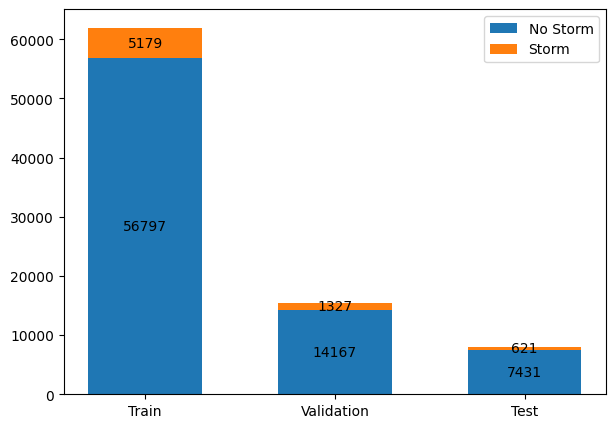

In [20]:
type = ('Train', 'Validation', 'Test')

storm_counts = {
    'No Storm': np.array([y_train.value_counts()[0], y_val.value_counts()[0], y_test.value_counts()[0]]),
    'Storm': np.array([y_train.value_counts()[1], y_val.value_counts()[1] , y_test.value_counts()[1]]),
}
width = 0.6  # the width of the bars: can also be len(x) sequence

fig, ax = plt.subplots(figsize=(7,5))
bottom = np.zeros(3)

for mode, count in storm_counts.items():
    p = ax.bar(type, count, width, label=mode, bottom=bottom)
    bottom += count

    ax.bar_label(p, label_type='center')

ax.legend()

plt.show()

#### Normalising the features

In [21]:
# normalise data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

In [22]:
#dump(scaler, 'Dakar-t3.bin', compress=True)

In [23]:
initial_bias = np.log(pos/neg)
output_bias = tf.keras.initializers.Constant(value=initial_bias)

model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(len(data.keys())-1,)),
  tf.keras.layers.Dense(32, activation='relu', kernel_initializer=he_normal()),
  tf.keras.layers.Dropout(0.2),    
  tf.keras.layers.Dense(16, activation='relu'),
  tf.keras.layers.Dense(8, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid', bias_initializer=output_bias)
])

l1_reg = tf.keras.regularizers.L1(0.1)
for layer in model.layers[:]:
  layer.kernel_regularizer = l1_reg

cl_thresholds = 0.3

METRICS = [
      tf.keras.metrics.MeanSquaredError(name='bs'),
      tf.keras.metrics.TruePositives(name='tp'),
      tf.keras.metrics.TrueNegatives(name='tn'),                        
      tf.keras.metrics.Recall(name='recall', thresholds = cl_thresholds),
      tf.keras.metrics.Precision(name='precision', thresholds = cl_thresholds),
      tf.keras.metrics.AUC(name='auc'),
      tf.keras.metrics.AUC(name='prc', curve='PR'), 
      tf.keras.metrics.F1Score(name = 'f1_score',  threshold = cl_thresholds),
]


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=METRICS)

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625 (10.25 KB)

 Trainable params: 2,625 (10.25 KB)

 Non-trainable params: 0 (0.00 B)

### Training

In [25]:
EPOCHS = 500
BATCH_SIZE = 1024

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_prc", 
    verbose=1,
    patience=10,
    mode='max',
    restore_best_weights=True)


# train the model
model_history = model.fit(x_train, 
                          y_train, 
                          epochs=EPOCHS, 
                          callbacks = [early_stopping],
                          batch_size = BATCH_SIZE,         
                          validation_data=(x_val, y_val),
                        )

Epoch 1/500


61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - auc: 0.6180 - bs: 0.0727 - f1_score: 0.1198 - loss: 0.2746 - prc: 0.1693 - precision: 0.3335 - recall: 0.0813 - tn: 29469.9668 - tp: 98.3871 - val_auc: 0.8796 - val_bs: 0.0606 - val_f1_score: 0.4550 - val_loss: 0.2076 - val_prc: 0.4024 - val_precision: 0.4564 - val_recall: 0.4537 - val_tn: 14008.0000 - val_tp: 180.0000
Epoch 2/500
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - auc: 0.8721 - bs: 0.0617 - f1_score: 0.4247 - loss: 0.2104 - prc: 0.3906 - precision: 0.4439 - recall: 0.4074 - tn: 29084.1289 - tp: 453.5645 - val_auc: 0.9013 - val_bs: 0.0571 - val_f1_score: 0.5026 - val_loss: 0.1916 - val_prc: 0.4547 - val_precision: 0.4974 - val_recall: 0.5079 - val_tn: 14027.0000 - val_tp: 213.0000
Epoch 3/500
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.8956 - bs: 0.0569 - f1_score: 0.4753 - loss: 0.1918 - prc: 0.4425 - precision: 0.4762 - recall: 0.4748 - tn: 29127.3555 - tp: 545.1129 - val_auc: 0.9090 - val_bs: 0.0555 - val_f1_score: 0.5323 - val_los

In [26]:
def class_prediction(x, y):
    y_hat = model.predict(x)      
    bs = brier_score_loss(y, y_hat)    
    auc = roc_auc_score(y, y_hat)
    return y_hat, auc, bs

In [27]:
def plot_cm(y, y_hat, classification_threshold):
    # compute the contingency table    
    y_hat_class = y_hat >= classification_threshold
    cm = metrics.confusion_matrix(y, y_hat_class)
    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'Blues_r', cbar=None, fmt='g')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

In [28]:
def plot_metrics(history):
  metrics = ['loss', 'bs', 'recall', 'precision']
  for n, metric in enumerate(metrics):
    name = metric.replace("_"," ").capitalize()
    plt.subplot(2,2,n+1)
    plt.plot(history.epoch, history.history[metric], color="red", label='Train')
    plt.plot(history.epoch, history.history['val_'+metric],
             color=colors[0], linestyle="--", label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel(name)
    if metric == 'loss':
      plt.ylim([0, plt.ylim()[1]])
    elif metric == 'auc':
      plt.ylim([0.5,1])
    else:
      plt.ylim([0,1])

    plt.legend()

### Performance on training data

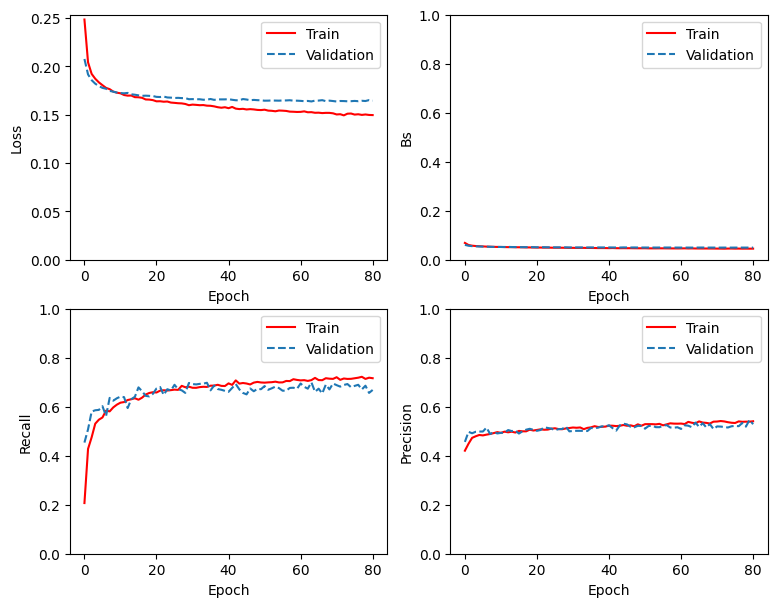

In [29]:
plot_metrics(model_history)

### Performance on testing data

In [30]:
def cutoff_youdens_j(fpr, tpr, thresholds):
    j_scores = tpr-fpr
    j_ordered = sorted(zip(j_scores, thresholds))
    return j_ordered[-1][1]

485/485 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
0.06034404


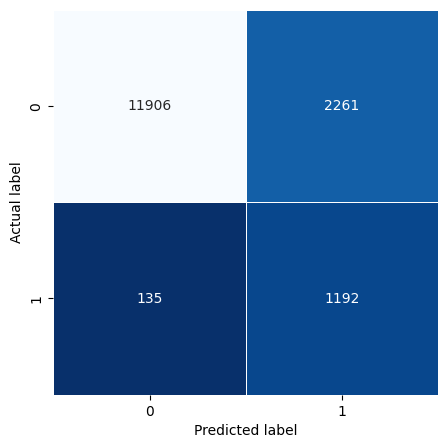

In [31]:
y_hat_val, auc_val, bs_val = class_prediction(x_val, y_val)
classification_threshold_val = cutoff_youdens_j(*roc_curve(y_val, y_hat_val))
print(classification_threshold_val)
plot_cm(y_val, y_hat_val, classification_threshold=classification_threshold_val)

In [32]:
average_precision_score(y_val, y_hat_val)

0.5744469944386646

252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


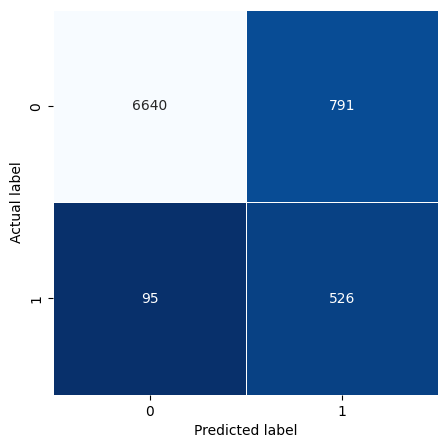

In [33]:
y_hat_test, auc_test, bs_test = class_prediction(x_test, y_test)
classification_threshold = cutoff_youdens_j(*roc_curve(y_test, y_hat_test))
plot_cm(y_test, y_hat_test, classification_threshold=classification_threshold_val)

In [34]:
average_precision_score(y_test, y_hat_test)

0.6107962680322758

In [35]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

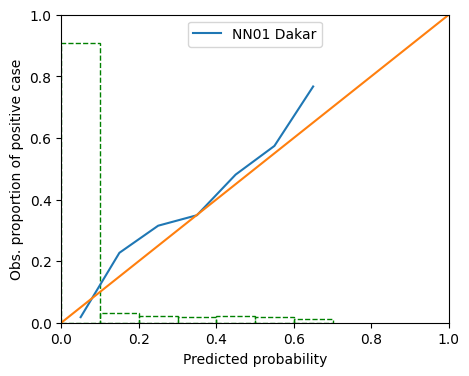

In [43]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test, y_hat_test.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"NN01 Dakar")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

In [37]:
#model.save('/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Dakar-t3.keras')

In [38]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

In [39]:
y_hat_train, auc_train, bs_train = class_prediction(x_train, y_train)

1937/1937 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


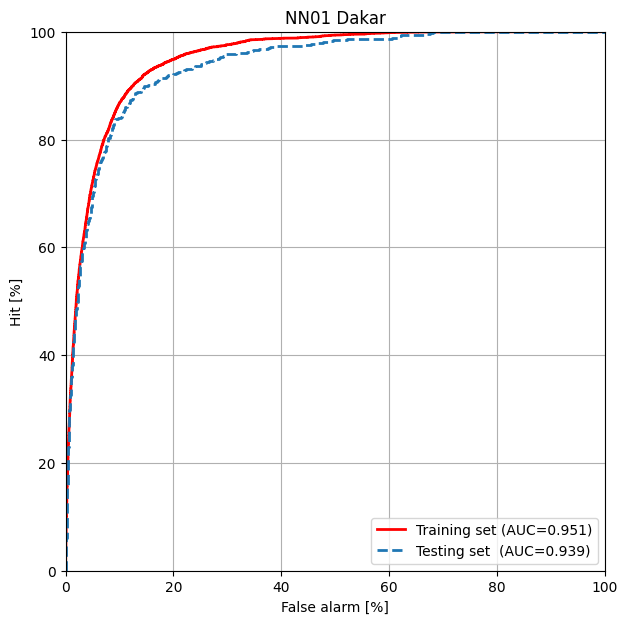

In [40]:
plot_roc(f"Training set (AUC={auc_train:.3f})", y_train, y_hat_train, color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", y_test, y_hat_test, color=colors[0], linestyle='--')
plt.title("NN01 Dakar")
plt.legend(loc='lower right');

In [41]:
def plot_prc(name, labels, predictions, **kwargs):
    precision, recall, _ = metrics.precision_recall_curve(labels, predictions)
    plt.plot(precision, recall, label=name, linewidth=2, **kwargs)
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.grid(True)
    ax = plt.gca()
    ax.set_aspect('equal')

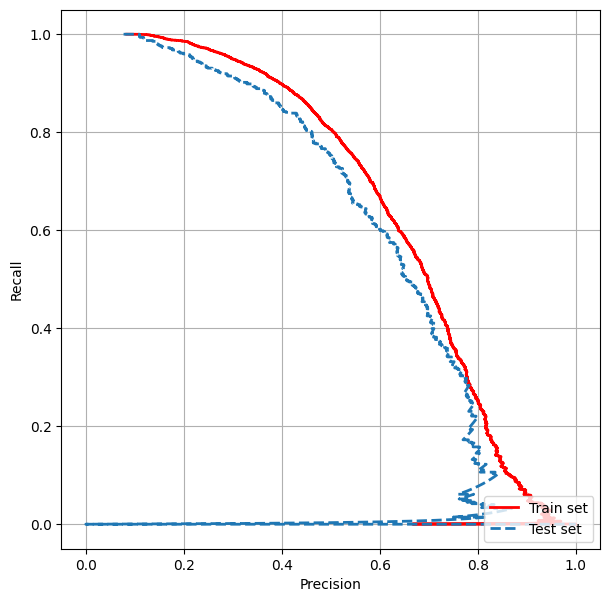

In [42]:
plot_prc("Train set", y_train, y_hat_train, color="red")
plot_prc("Test set", y_test, y_hat_test, color=colors[0], linestyle='--')
plt.legend(loc='lower right');

In [94]:
model_t0 = tf.keras.models.load_model("/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/best_model_new_format_Dakar_nearest5_corrected.keras")
scaler_t0 = load('/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/std_scaler_best_model_new_format_Dakar_nearest5_corrected.bin')

In [123]:
field_t1 = t1 + loc_t1 + wp_t1 + sz_t1 + ds_t1 + target_index
field_t1 = field_t1.split(',')

In [124]:
test_data_t1 = original_test_data[field_t1]

In [ ]:
columns={'year_t1':'year',
        'month_t1':'month',
        'day_t1':'day',
        'hour_t1':'hour',
        'minute_t1':'minute',
        'lat1_t1':'lat1',
        'lon1_t1':'lon1',
        'lat2_t1':'lat2',
        'lon2_t1':'lon2',
        'lat3_t1':'lat3',
        'lon3_t1':'lon3',
        'lat4_t1':'lat4',
        'lon4_t1':'lon4',
        'lat5_t1':'lat5',
        'lon5_t1':'lon5',
        'wp1_t1':'wp1',
        'wp2_t1':'wp2',
        'wp3_t1':'wp3',
        'wp4_t1':'wp4',
        'wp5_t1':'wp5',
        'size1_t1':'size1',
        'size2_t1':'size2',
        'size3_t1':'size3',
        'size4_t1':'size4',
        'size5_t1':'size5',
        'ds1_t1':'ds1',
        'ds2_t1':'ds2',
        'ds3_t1':'ds3',
        'ds4_t1':'ds4',
        'ds5_t1':'ds5',
        'Cb_Dakar_t2':'Cb_Dakar_t2'}

In [125]:
test_data_t1 = test_data_t1.rename(columns={'year_t1':'year',
'month_t1':'month',
'day_t1':'day',
'hour_t1':'hour',
'minute_t1':'minute',
'lat1_t1':'lat1',
'lon1_t1':'lon1',
'lat2_t1':'lat2',
'lon2_t1':'lon2',
'lat3_t1':'lat3',
'lon3_t1':'lon3',
'lat4_t1':'lat4',
'lon4_t1':'lon4',
'lat5_t1':'lat5',
'lon5_t1':'lon5',
'wp1_t1':'wp1',
'wp2_t1':'wp2',
'wp3_t1':'wp3',
'wp4_t1':'wp4',
'wp5_t1':'wp5',
'size1_t1':'size1',
'size2_t1':'size2',
'size3_t1':'size3',
'size4_t1':'size4',
'size5_t1':'size5',
'ds1_t1':'ds1',
'ds2_t1':'ds2',
'ds3_t1':'ds3',
'ds4_t1':'ds4',
'ds5_t1':'ds5',
'Cb_Dakar_t2':'Cb_Dakar_t2'})


In [126]:
test_data_t1

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5,Cb_Dakar_t2
0,2020,6,1,1.0,0.0,10.38,-16.08,10.11,-17.12,10.65,...,4175,4550,0.0,0.0,153.63,155.98,161.00,430.00,430.00,0.0
1,2020,6,1,1.0,15.0,10.15,-17.21,10.38,-16.17,10.78,...,7625,4600,0.0,0.0,149.05,154.35,160.03,430.00,430.00,0.0
2,2020,6,1,1.0,30.0,10.78,-15.41,10.42,-16.22,10.20,...,6950,3725,0.0,0.0,148.25,153.17,158.11,430.00,430.00,0.0
3,2020,6,1,2.0,0.0,10.56,-16.35,10.29,-17.48,14.00,...,1675,0,0.0,0.0,147.49,155.46,430.00,430.00,430.00,0.0
4,2020,6,1,2.0,15.0,10.65,-16.40,10.38,-17.57,14.00,...,975,0,0.0,0.0,144.18,152.74,430.00,430.00,430.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8137,2021,7,28,0.0,0.0,10.38,-14.60,12.04,-15.18,12.76,...,6575,12900,19825.0,10850.0,86.45,115.60,135.20,173.77,312.85,0.0
8138,2021,7,28,0.0,15.0,12.04,-15.32,10.38,-14.60,12.80,...,13425,13975,8675.0,24925.0,112.65,129.00,173.77,304.77,347.52,0.0
8139,2021,7,28,0.0,30.0,10.51,-16.58,12.85,-14.11,10.42,...,13925,8150,14350.0,32050.0,108.72,125.90,148.10,171.54,351.06,0.0
8140,2021,7,28,0.0,45.0,13.07,-13.88,10.56,-16.67,10.24,...,450,15075,31975.0,0.0,129.28,145.88,168.32,323.95,430.00,0.0


In [127]:
to_scale = 'wp1,wp2,wp3,wp4,wp5,size1,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5,'

In [129]:
test_data_t1 = log_transform(test_data_t1, to_scale.split(',')[:-1])    
test_data_t1 = sqrt_transform(test_data_t1, 'year,month,day,hour,minute,'.split(',')[:-1])

In [130]:
x_test_t1 = test_data_t1.drop([target_index], axis=1)
y_test_t1 = test_data_t1[target_index]

In [131]:
x_test_t1

,year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,...,size1,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5
0,44.944410,2.449490,1.000000,1.000000,0.000000,10.38,-16.08,10.11,-17.12,10.65,...,9.235033,8.336870,8.422883,-18.420681,-18.420681,5.034547,5.049728,5.081404,6.063785,6.063785
1,44.944410,2.449490,1.000000,1.000000,3.872983,10.15,-17.21,10.38,-16.17,10.78,...,8.798606,8.939188,8.433812,-18.420681,-18.420681,5.004282,5.039223,5.075361,6.063785,6.063785
2,44.944410,2.449490,1.000000,1.000000,5.477226,10.78,-15.41,10.42,-16.22,10.20,...,8.455318,8.846497,8.222822,-18.420681,-18.420681,4.998900,5.031548,5.063291,6.063785,6.063785
3,44.944410,2.449490,1.000000,1.414214,0.000000,10.56,-16.35,10.29,-17.48,14.00,...,8.686936,7.423568,-18.420681,-18.420681,-18.420681,4.993760,5.046388,6.063785,6.063785,6.063785
4,44.944410,2.449490,1.000000,1.414214,3.872983,10.65,-16.40,10.38,-17.57,14.00,...,8.527144,6.882437,-18.420681,-18.420681,-18.420681,4.971063,5.028737,6.063785,6.063785,6.063785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8137,44.955534,2.645751,5.291503,0.000000,0.000000,10.38,-14.60,12.04,-15.18,12.76,...,7.438384,8.791030,9.464983,9.894699,9.291920,4.459566,4.750136,4.906755,5.157733,5.745724
8138,44.955534,2.645751,5.291503,0.000000,3.872983,12.04,-15.32,10.38,-14.60,12.80,...,8.138857,9.504874,9.545025,9.068201,10.123627,4.724286,4.859812,5.157733,5.719557,5.850822
8139,44.955534,2.645751,5.291503,0.000000,5.477226,10.51,-16.58,12.85,-14.11,10.42,...,7.069023,9.541441,9.005773,9.571505,10.375052,4.688776,4.835488,4.997888,5.144816,5.860957
8140,44.955534,2.645751,5.291503,0.000000,6.708204,13.07,-13.88,10.56,-16.67,10.24,...,9.600692,6.109248,9.620793,10.372710,-18.420681,4.861981,4.982784,5.125867,5.780589,6.063785


In [132]:
x_test_t1_std = scaler_t0.transform(x_test_t1)

In [134]:
y_test_t1_pred = model_t0.predict(x_test_t1_std)

252/252 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


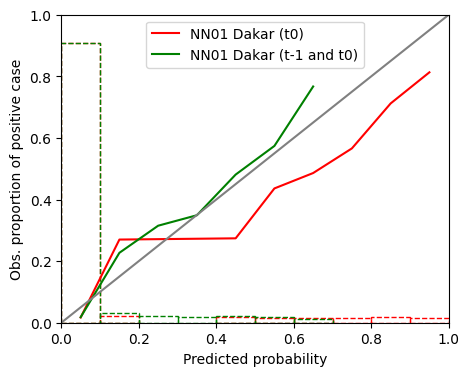

In [148]:
prob_pred_t1, prob_true_t1, no_pred_per_bin_t1 = reliability_curve(y_test_t1, y_test_t1_pred.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred_t1, prob_true_t1, label=f"NN01 Dakar (t0)", color="red")    
plt.plot(prob_pred, prob_true, label=f"NN01 Dakar (t-1 and t0)", color="green")    

    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin_t1 = [i/(1.1*np.max(no_pred_per_bin_t1)) for i in no_pred_per_bin_t1]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2), color="gray")
plt.bar(prob_pred_t1, no_pred_per_bin_t1, width=0.1, linestyle="--", fill=False, edgecolor="red")
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

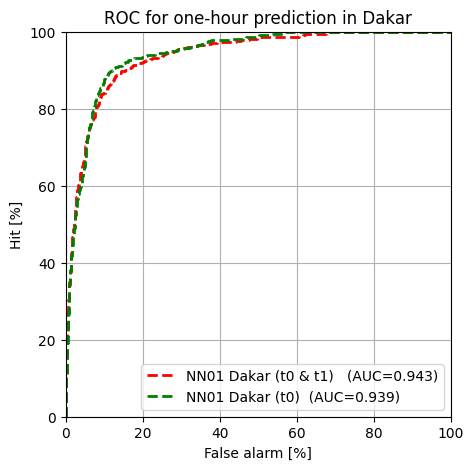

In [158]:
mpl.rcParams['figure.figsize'] = (8, 5)
auc_test_t1 = roc_auc_score(y_test_t1, y_test_t1_pred)
plot_roc(f"NN01 Dakar (t0 & t1)   (AUC={auc_test_t1:.3f})", y_test, y_hat_test, color="red", linestyle='--')
plot_roc(f"NN01 Dakar (t0)  (AUC={auc_test:.3f})", y_test_t1, y_test_t1_pred, color="green", linestyle='--')
plt.title("ROC for one-hour prediction in Dakar")
plt.legend(loc='lower right');